# Corporate Financial Performance Analytics — Clean Pipeline
**BP, Chevron (CVX), Shell (SHEL), ExxonMobil (XOM) — 2022-2025**

This is a cleaned, consolidated rebuild of the project notebook. It removes:
- duplicate/failed attempts and dead-end error cells from earlier debugging sessions
- repeated imports and empty section-header cells
- one-off diagnostic prints no longer needed

**Scope note:** this notebook starts from the three processed master files you
already built (`master_income_statement.csv`, `comparable_balance_sheet_2022_2025.csv`,
`master_cash_flow.csv`) rather than re-running the raw yfinance download and
master-dataset build again — those already worked and don't need to be redone.
If you also want the raw-download stage cleaned up into its own notebook, that's
a separate, smaller job — just ask.

Every phase below is labelled to match your original project plan (Phases 6-18).

In [34]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

# ================================================================
# CONFIG — update this path to match your machine
# ================================================================
BASE_PATH = Path(r"D:\Mohamed Mounir\financial analysis\Oil and Gas\data\processed")

INCOME_PATH   = BASE_PATH / "master_income_statement.csv"
BALANCE_PATH  = BASE_PATH / "comparable_balance_sheet_2022_2025.csv"
CASHFLOW_PATH = BASE_PATH / "master_cash_flow.csv"
OUTPUT_XLSX   = BASE_PATH / "Corporate_Financial_Analysis_2022_2025.xlsx"

TICKERS = ["XOM", "CVX", "SHEL", "BP"]
START_YEAR, END_YEAR = 2022, 2025

## Section 1 — Load Master Datasets & Build a Clean KPI Base Table

In [35]:
# ================================================================
# LOAD MASTER DATASETS
# ================================================================
income   = pd.read_csv(INCOME_PATH)
balance  = pd.read_csv(BALANCE_PATH)
cashflow = pd.read_csv(CASHFLOW_PATH)

print("Income   :", income.shape)
print("Balance  :", balance.shape)
print("Cash Flow:", cashflow.shape)

Income   : (19, 57)
Balance  : (16, 116)
Cash Flow: (16, 13)


In [36]:
# ================================================================
# STANDARDIZE TICKER + YEAR ACROSS ALL THREE SOURCES
# ================================================================
for df in [income, balance, cashflow]:
    df["Ticker"] = df["Ticker"].astype(str).str.strip().str.upper()

def to_year(df, fallback_col=None):
    col = "Year" if "Year" in df.columns else fallback_col
    if col is None:
        raise KeyError("No Year/Year_Date column found.")
    series = df[col]
    if pd.api.types.is_numeric_dtype(series):
        # Already a plain year number (e.g. 2022) -- use as-is, do NOT
        # run through pd.to_datetime (it would misinterpret 2022 as a
        # nanosecond timestamp and silently corrupt every year value).
        df["Year"] = series.astype(int)
    else:
        # A date-like string/object column -- safe to parse as a date.
        df["Year"] = pd.to_datetime(series, errors="coerce").dt.year
    return df

income   = to_year(income, fallback_col="Year_Date")
balance  = to_year(balance, fallback_col="Year_Date")
cashflow = to_year(cashflow, fallback_col="Year_Date")

for name, df in {"Income": income, "Balance": balance, "Cash Flow": cashflow}.items():
    df.query("@START_YEAR <= Year <= @END_YEAR", inplace=False)

income   = income[income["Year"].between(START_YEAR, END_YEAR)].copy()
balance  = balance[balance["Year"].between(START_YEAR, END_YEAR)].copy()
cashflow = cashflow[cashflow["Year"].between(START_YEAR, END_YEAR)].copy()

print("Filtered to", START_YEAR, "-", END_YEAR)
print("Income   :", len(income))
print("Balance  :", len(balance))
print("Cash Flow:", len(cashflow))

Filtered to 2022 - 2025
Income   : 16
Balance  : 16
Cash Flow: 16


In [37]:
# ================================================================
# STANDARDIZE RECEIVABLES
# (BP/SHEL report "Accounts Receivable" (IFRS); CVX/XOM report "Receivables")
# This fully replaces the manual Excel patch used earlier — it's now
# handled in code, once, with full lineage tracking via Receivables_Source.
# ================================================================
receivable_cols = [c for c in ["Ticker", "Year", "Receivables", "Accounts Receivable"] if c in balance.columns]
receivables = balance[receivable_cols].copy()

receivables["Receivables_Standard"] = np.nan
receivables["Receivables_Source"] = "MISSING"

if "Receivables" in receivables.columns:
    mask = receivables["Receivables"].notna()
    receivables.loc[mask, "Receivables_Standard"] = receivables.loc[mask, "Receivables"]
    receivables.loc[mask, "Receivables_Source"] = "Receivables"

if "Accounts Receivable" in receivables.columns:
    mask = receivables["Receivables_Standard"].isna() & receivables["Accounts Receivable"].notna()
    receivables.loc[mask, "Receivables_Standard"] = receivables.loc[mask, "Accounts Receivable"]
    receivables.loc[mask, "Receivables_Source"] = "Accounts Receivable"

receivables = receivables[["Ticker", "Year", "Receivables_Standard", "Receivables_Source"]].copy()

print(receivables.sort_values(["Ticker", "Year"]))

   Ticker  Year  Receivables_Standard   Receivables_Source
15     BP  2022          2.822900e+10  Accounts Receivable
14     BP  2023          2.517500e+10  Accounts Receivable
13     BP  2024          2.165900e+10  Accounts Receivable
12     BP  2025          2.601400e+10  Accounts Receivable
7     CVX  2022          2.045600e+10          Receivables
6     CVX  2023          1.992100e+10          Receivables
5     CVX  2024          2.068400e+10          Receivables
4     CVX  2025          1.807500e+10          Receivables
11   SHEL  2022          3.933400e+10  Accounts Receivable
10   SHEL  2023          3.627300e+10  Accounts Receivable
9    SHEL  2024          3.104100e+10  Accounts Receivable
8    SHEL  2025          3.000500e+10  Accounts Receivable
3     XOM  2022          4.174900e+10          Receivables
2     XOM  2023          3.801500e+10          Receivables
1     XOM  2024          4.368100e+10          Receivables
0     XOM  2025          4.456200e+10          Receivabl

In [38]:
# ================================================================
# SELECT KPI-RELEVANT FIELDS FROM EACH SOURCE
# (includes Cash And Cash Equivalents and Tax Rate For Calcs,
#  which earlier versions of this pipeline were missing — that's what
#  caused the Cash Ratio / ROIC KeyErrors during the session.)
# ================================================================
income_fields = [
    "Ticker", "Year", "Total Revenue", "Gross Profit", "Operating Income",
    "EBITDA", "EBIT", "Net Income", "Interest Expense", "Total Expenses",
    "Tax Rate For Calcs",
]
balance_fields = [
    "Ticker", "Year", "Total Assets", "Current Assets", "Current Liabilities",
    "Working Capital", "Total Debt", "Net Debt", "Stockholders Equity",
    "Inventory", "Cash And Cash Equivalents",
]
cashflow_fields = [
    "Ticker", "Year", "Operating Cash Flow", "Free Cash Flow",
    "Capital Expenditure", "Capital Expenditure Reported",
    "Investing Cash Flow", "Financing Cash Flow",
]

income_fields   = [c for c in income_fields if c in income.columns]
balance_fields  = [c for c in balance_fields if c in balance.columns]
cashflow_fields = [c for c in cashflow_fields if c in cashflow.columns]

missing_income   = [c for c in ["Tax Rate For Calcs"] if c not in income.columns]
missing_balance  = [c for c in ["Cash And Cash Equivalents"] if c not in balance.columns]
if missing_income:
    print("WARNING - not found in income source, check raw column names:", missing_income)
if missing_balance:
    print("WARNING - not found in balance source, check raw column names:", missing_balance)

income_kpi   = income[income_fields].copy()
balance_kpi  = balance[balance_fields].copy()
cashflow_kpi = cashflow[cashflow_fields].copy()

In [39]:
# ================================================================
# BUILD kpi_df — ONE CLEAN MERGE, NO REPEATED PATCHES
# ================================================================
kpi_df = income_kpi.merge(balance_kpi, on=["Ticker", "Year"], how="outer")
kpi_df = kpi_df.merge(cashflow_kpi, on=["Ticker", "Year"], how="outer")
kpi_df = kpi_df.merge(receivables, on=["Ticker", "Year"], how="left")
kpi_df = kpi_df.rename(columns={"Receivables_Standard": "Receivables"})

kpi_df = kpi_df[kpi_df["Year"].between(START_YEAR, END_YEAR)].copy()
kpi_df = kpi_df.sort_values(["Ticker", "Year"]).reset_index(drop=True)

duplicate_count = kpi_df.duplicated(subset=["Ticker", "Year"], keep=False).sum()

print("=" * 70)
print("KPI BASE TABLE")
print("=" * 70)
print("Rows:", len(kpi_df), "| Columns:", len(kpi_df.columns))
print("Duplicate Ticker-Year rows:", duplicate_count)
print("Receivables populated:", kpi_df["Receivables"].notna().sum(), "/", len(kpi_df))
kpi_df.head()

KPI BASE TABLE
Rows: 16 | Columns: 28
Duplicate Ticker-Year rows: 0
Receivables populated: 16 / 16


,Ticker,Year,Total Revenue,Gross Profit,Operating Income,EBITDA,EBIT,Net Income,Interest Expense,Total Expenses,...,Inventory,Cash And Cash Equivalents,Operating Cash Flow,Free Cash Flow,Capital Expenditure,Capital Expenditure Reported,Investing Cash Flow,Financing Cash Flow,Receivables,Receivables_Source
0,BP,2022,2.413920e+11,5.509600e+10,4.144700e+10,3.234600e+10,1.802800e+10,-2.487000e+09,2.623000e+09,1.999450e+11,...,2.808100e+10,2.332900e+10,40932000000,28863000000,-12069000000,-12069000000,-13713000000,-28021000000,2.822900e+10,Accounts Receivable
1,BP,2023,2.101300e+11,4.807200e+10,3.104900e+10,4.350300e+10,2.757500e+10,1.523900e+10,3.826000e+09,1.790810e+11,...,2.281900e+10,2.774800e+10,32039000000,17754000000,-14285000000,-14285000000,-14872000000,-13359000000,2.517500e+10,Accounts Receivable
2,BP,2024,1.891850e+11,3.023900e+10,1.361500e+10,2.798300e+10,1.136100e+10,3.810000e+08,4.579000e+09,1.755700e+11,...,2.323200e+10,3.436000e+10,27297000000,12000000000,-15297000000,-15297000000,-13250000000,-7297000000,2.165900e+10,Accounts Receivable
3,BP,2025,1.893350e+11,3.352900e+10,1.580800e+10,3.069600e+10,1.287400e+10,5.500000e+07,5.128000e+09,1.735270e+11,...,2.249900e+10,3.655600e+10,24493000000,11272000000,-13221000000,-13221000000,-11504000000,-15880000000,2.601400e+10,Accounts Receivable
4,CVX,2022,2.357170e+11,7.398200e+10,3.995000e+10,6.548500e+10,5.019000e+10,3.546500e+10,5.160000e+08,1.957670e+11,...,8.247000e+09,1.767800e+10,49602000000,37628000000,-11974000000,-11974000000,-12108000000,-24978000000,2.045600e+10,Receivables


## Section 2 — Phase 6: Liquidity Analysis

In [40]:
kpi_df["Current Ratio"] = kpi_df["Current Assets"] / kpi_df["Current Liabilities"]
kpi_df["Quick Ratio"] = (kpi_df["Current Assets"] - kpi_df["Inventory"]) / kpi_df["Current Liabilities"]
kpi_df["Cash Ratio"] = kpi_df["Cash And Cash Equivalents"] / kpi_df["Current Liabilities"]
if "Working Capital" not in kpi_df.columns:
    kpi_df["Working Capital"] = kpi_df["Current Assets"] - kpi_df["Current Liabilities"]

print("LIQUIDITY RATIOS")
kpi_df[["Ticker", "Year", "Current Ratio", "Quick Ratio", "Cash Ratio", "Working Capital"]]

LIQUIDITY RATIOS


,Ticker,Year,Current Ratio,Quick Ratio,Cash Ratio,Working Capital
0,BP,2022,1.087560,0.803965,0.235604,8.670000e+09
1,BP,2023,1.209903,0.944806,0.322359,1.806800e+10
2,BP,2024,1.250398,0.967911,0.417796,2.059300e+10
3,BP,2025,1.263151,0.983942,0.453655,2.120500e+10
4,CVX,2022,1.471673,1.230589,0.516780,1.613500e+10
5,CVX,2023,1.274971,1.007998,0.253519,8.870000e+09
6,CVX,2024,1.061025,0.825691,0.175865,2.353000e+09
7,CVX,2025,1.154701,0.863839,0.188487,5.165000e+09
8,SHEL,2022,1.367873,1.104962,0.330473,4.462700e+10
9,SHEL,2023,1.404831,1.132287,0.401332,3.864800e+10


## Section 3 — Phase 7: Solvency & Leverage

In [41]:
kpi_df["Debt to Equity"] = kpi_df["Total Debt"] / kpi_df["Stockholders Equity"]
kpi_df["Debt to Assets"] = kpi_df["Total Debt"] / kpi_df["Total Assets"]
kpi_df["Net Debt to EBITDA"] = kpi_df["Net Debt"] / kpi_df["EBITDA"]
kpi_df["Debt to Capital"] = kpi_df["Total Debt"] / (kpi_df["Total Debt"] + kpi_df["Stockholders Equity"])
kpi_df["Equity Ratio"] = kpi_df["Stockholders Equity"] / kpi_df["Total Assets"]

print("SOLVENCY & LEVERAGE RATIOS")
kpi_df[["Ticker", "Year", "Debt to Equity", "Debt to Assets", "Net Debt to EBITDA",
        "Debt to Capital", "Equity Ratio"]]

SOLVENCY & LEVERAGE RATIOS

,Ticker,Year,Debt to Equity,Debt to Assets,Net Debt to EBITDA,Debt to Capital,Equity Ratio
0,BP,2022,0.821474,0.192604,0.730075,0.450994,0.234461
1,BP,2023,0.897443,0.225032,0.556421,0.472975,0.250747
2,BP,2024,1.207626,0.253508,0.900082,0.547025,0.209922
3,BP,2025,1.367130,0.260403,0.697224,0.577548,0.190474
4,CVX,2022,0.146526,0.090563,0.079606,0.127800,0.618069
5,CVX,2023,0.129451,0.079639,0.251469,0.114614,0.615204
6,CVX,2024,0.161117,0.095513,0.374495,0.138760,0.592820
7,CVX,2025,0.218600,0.125792,0.797257,0.179386,0.575442
8,SHEL,2022,0.439933,0.189143,0.173542,0.305523,0.429936
9,SHEL,2023,0.436966,0.200706,0.257087,0.304090,0.459318


## Section 4 — Phase 8: Interest Coverage

In [42]:
kpi_df["Interest Coverage"] = kpi_df["EBIT"] / kpi_df["Interest Expense"].abs()
kpi_df["Interest Coverage"] = kpi_df["Interest Coverage"].replace([np.inf, -np.inf], np.nan)

print("INTEREST COVERAGE")
kpi_df[["Ticker", "Year", "EBIT", "Interest Expense", "Interest Coverage"]]

INTEREST COVERAGE


,Ticker,Year,EBIT,Interest Expense,Interest Coverage
0,BP,2022,1.802800e+10,2.623000e+09,6.873046
1,BP,2023,2.757500e+10,3.826000e+09,7.207266
2,BP,2024,1.136100e+10,4.579000e+09,2.481109
3,BP,2025,1.287400e+10,5.128000e+09,2.510530
4,CVX,2022,5.019000e+10,5.160000e+08,97.267442
5,CVX,2023,3.005300e+10,4.690000e+08,64.078891
6,CVX,2024,2.810000e+10,5.940000e+08,47.306397
7,CVX,2025,2.096000e+10,1.217000e+09,17.222679
8,SHEL,2022,7.016100e+10,5.346000e+09,13.124018
9,SHEL,2023,3.725500e+10,4.628000e+09,8.049914


## Section 5 — Phase 9: Profitability

In [43]:
kpi_df["Gross Margin"] = kpi_df["Gross Profit"] / kpi_df["Total Revenue"]
kpi_df["Operating Margin"] = kpi_df["Operating Income"] / kpi_df["Total Revenue"]
kpi_df["EBITDA Margin"] = kpi_df["EBITDA"] / kpi_df["Total Revenue"]
kpi_df["EBIT Margin"] = kpi_df["EBIT"] / kpi_df["Total Revenue"]
kpi_df["Net Profit Margin"] = kpi_df["Net Income"] / kpi_df["Total Revenue"]

print("PROFITABILITY RATIOS")
kpi_df[["Ticker", "Year", "Gross Margin", "Operating Margin", "EBITDA Margin",
        "EBIT Margin", "Net Profit Margin"]]

PROFITABILITY RATIOS


,Ticker,Year,Gross Margin,Operating Margin,EBITDA Margin,EBIT Margin,Net Profit Margin
0,BP,2022,0.228243,0.171700,0.133998,0.074684,-0.010303
1,BP,2023,0.228773,0.147761,0.207029,0.131228,0.072522
2,BP,2024,0.159838,0.071967,0.147913,0.060052,0.002014
3,BP,2025,0.177088,0.083492,0.162125,0.067996,0.000290
4,CVX,2022,0.313859,0.169483,0.277812,0.212925,0.150456
5,CVX,2023,0.306689,0.133201,0.242823,0.152621,0.108520
6,CVX,2024,0.294322,0.097806,0.236855,0.145284,0.091312
7,CVX,2025,0.304101,0.090407,0.224565,0.113646,0.066686
8,SHEL,2022,0.206599,0.165504,0.242724,0.183998,0.110956
9,SHEL,2023,0.149097,0.097079,0.190642,0.117665,0.061143


## Section 6 — Phase 10: Returns (ROA, ROE, ROIC)

In [44]:
kpi_df["ROA"] = kpi_df["Net Income"] / kpi_df["Total Assets"]
kpi_df["ROE"] = kpi_df["Net Income"] / kpi_df["Stockholders Equity"]

kpi_df["NOPAT"] = kpi_df["EBIT"] * (1 - kpi_df["Tax Rate For Calcs"])
kpi_df["Invested Capital"] = kpi_df["Total Debt"] + kpi_df["Stockholders Equity"]
kpi_df["ROIC"] = kpi_df["NOPAT"] / kpi_df["Invested Capital"]

print("RETURN RATIOS")
kpi_df[["Ticker", "Year", "ROA", "ROE", "NOPAT", "Invested Capital", "ROIC"]]

RETURN RATIOS


,Ticker,Year,ROA,ROE,NOPAT,Invested Capital,ROIC
0,BP,2022,-0.008632,-0.036816,1.460268e+10,1.230460e+11,0.118677
1,BP,2023,0.054368,0.216823,1.847525e+10,1.333580e+11,0.138539
2,BP,2024,0.001350,0.006431,8.520750e+09,1.307930e+11,0.065147
3,BP,2025,0.000197,0.001037,9.655500e+09,1.255810e+11,0.076887
4,CVX,2022,0.137616,0.222655,3.598623e+10,1.826210e+11,0.197054
5,CVX,2023,0.081676,0.132762,2.175837e+10,1.817930e+11,0.119688
6,CVX,2024,0.068736,0.115948,1.812450e+10,1.768590e+11,0.102480
7,CVX,2025,0.037958,0.065964,1.324672e+10,2.272080e+11,0.058302
8,SHEL,2022,0.095500,0.222127,4.641031e+10,2.742670e+11,0.169216
9,SHEL,2023,0.047651,0.103742,2.242129e+10,2.681480e+11,0.083615


## Section 7 — Phase 11: Efficiency

In [45]:
kpi_df["Asset Turnover"] = kpi_df["Total Revenue"] / kpi_df["Total Assets"]
# Total Expenses used as a Cost of Revenue proxy (no separate COGS field available)
kpi_df["Inventory Turnover"] = kpi_df["Total Expenses"] / kpi_df["Inventory"]
kpi_df["Receivables Turnover"] = kpi_df["Total Revenue"] / kpi_df["Receivables"]
kpi_df["Days Sales Outstanding"] = (kpi_df["Receivables"] / kpi_df["Total Revenue"]) * 365
kpi_df["Days Inventory Outstanding"] = (kpi_df["Inventory"] / kpi_df["Total Expenses"]) * 365

print("EFFICIENCY RATIOS")
kpi_df[["Ticker", "Year", "Asset Turnover", "Inventory Turnover", "Receivables Turnover",
        "Days Sales Outstanding", "Days Inventory Outstanding"]]

EFFICIENCY RATIOS


,Ticker,Year,Asset Turnover,Inventory Turnover,Receivables Turnover,Days Sales Outstanding,Days Inventory Outstanding
0,BP,2022,0.837818,7.120295,8.551206,42.684037,51.261922
1,BP,2023,0.749677,7.847890,8.346773,43.729477,46.509317
2,BP,2024,0.670327,7.557249,8.734706,41.787325,48.298001
3,BP,2025,0.679775,7.712654,7.278196,50.149787,47.324826
4,CVX,2022,0.914663,23.737965,11.523123,31.675441,15.376213
5,CVX,2023,0.752633,19.819322,9.884695,36.925774,18.416372
6,CVX,2024,0.752765,19.230439,9.350899,39.033679,18.980326
7,CVX,2025,0.569213,17.275049,10.203707,35.771314,21.128739
8,SHEL,2022,0.860707,9.976955,9.694259,37.651148,36.584309
9,SHEL,2023,0.779334,10.987471,8.728807,41.815568,33.219656


## Section 8 — Phase 12-13: Operating & Free Cash Flow Quality

In [46]:
kpi_df["OCF Margin"] = kpi_df["Operating Cash Flow"] / kpi_df["Total Revenue"]
kpi_df["OCF to Net Income"] = kpi_df["Operating Cash Flow"] / kpi_df["Net Income"]
kpi_df["FCF Margin"] = kpi_df["Free Cash Flow"] / kpi_df["Total Revenue"]
kpi_df["FCF to Net Income"] = kpi_df["Free Cash Flow"] / kpi_df["Net Income"]
# abs() since Capital Expenditure is stored as a negative cash outflow
kpi_df["CapEx to Revenue"] = kpi_df["Capital Expenditure"].abs() / kpi_df["Total Revenue"]

ratio_cols = ["OCF Margin", "OCF to Net Income", "FCF Margin", "FCF to Net Income", "CapEx to Revenue"]
kpi_df[ratio_cols] = kpi_df[ratio_cols].replace([np.inf, -np.inf], np.nan)

print("CASH FLOW QUALITY")
kpi_df[["Ticker", "Year"] + ratio_cols]

CASH FLOW QUALITY


,Ticker,Year,OCF Margin,OCF to Net Income,FCF Margin,FCF to Net Income,CapEx to Revenue
0,BP,2022,0.169567,-16.458384,0.119569,-11.605549,0.049998
1,BP,2023,0.152472,2.102435,0.084491,1.165037,0.067982
2,BP,2024,0.144287,71.645669,0.063430,31.496063,0.080857
3,BP,2025,0.129363,445.327273,0.059535,204.945455,0.069829
4,CVX,2022,0.210430,1.398618,0.159632,1.060990,0.050798
5,CVX,2023,0.180836,1.666386,0.100450,0.925640,0.080386
6,CVX,2024,0.162822,1.783138,0.077781,0.851820,0.085040
7,CVX,2025,0.184019,2.759493,0.089963,1.349053,0.094056
8,SHEL,2022,0.179416,1.617008,0.120148,1.082843,0.059269
9,SHEL,2023,0.171155,2.799266,0.098535,1.611550,0.072620


## Section 9 — Year-over-Year Growth

In [47]:
kpi_df = kpi_df.sort_values(["Ticker", "Year"]).reset_index(drop=True)

growth_map = {
    "Total Revenue": "Revenue Growth",
    "EBITDA": "EBITDA Growth",
    "EBIT": "EBIT Growth",
    "Net Income": "Net Income Growth",
    "Operating Cash Flow": "OCF Growth",
    "Free Cash Flow": "FCF Growth",
}
for source_col, growth_col in growth_map.items():
    kpi_df[growth_col] = kpi_df.groupby("Ticker")[source_col].pct_change()

growth_cols = list(growth_map.values())
kpi_df[growth_cols] = kpi_df[growth_cols].replace([np.inf, -np.inf], np.nan)

print("GROWTH ANALYSIS (2022 is NaN by definition -- no prior year to compare)")
kpi_df[["Ticker", "Year"] + growth_cols]

GROWTH ANALYSIS (2022 is NaN by definition -- no prior year to compare)


,Ticker,Year,Revenue Growth,EBITDA Growth,EBIT Growth,Net Income Growth,OCF Growth,FCF Growth
0,BP,2022,NaN,NaN,NaN,NaN,NaN,NaN
1,BP,2023,-0.129507,0.344927,0.529565,-7.127463,-0.217263,-0.384887
2,BP,2024,-0.099676,-0.356757,-0.587996,-0.974998,-0.148007,-0.324096
3,BP,2025,0.000793,0.096952,0.133175,-0.855643,-0.102722,-0.060667
4,CVX,2022,NaN,NaN,NaN,NaN,NaN,NaN
5,CVX,2023,-0.164621,-0.269833,-0.401215,-0.397462,-0.282106,-0.474328
6,CVX,2024,-0.017769,-0.041912,-0.064985,-0.173522,-0.115617,-0.239434
7,CVX,2025,-0.046439,-0.095916,-0.254093,-0.303607,0.077702,0.102898
8,SHEL,2022,NaN,NaN,NaN,NaN,NaN,NaN
9,SHEL,2023,-0.169661,-0.347829,-0.469007,-0.542438,-0.207896,-0.319029


## Section 10 — Phase 14: Four-Year Trend Visualization

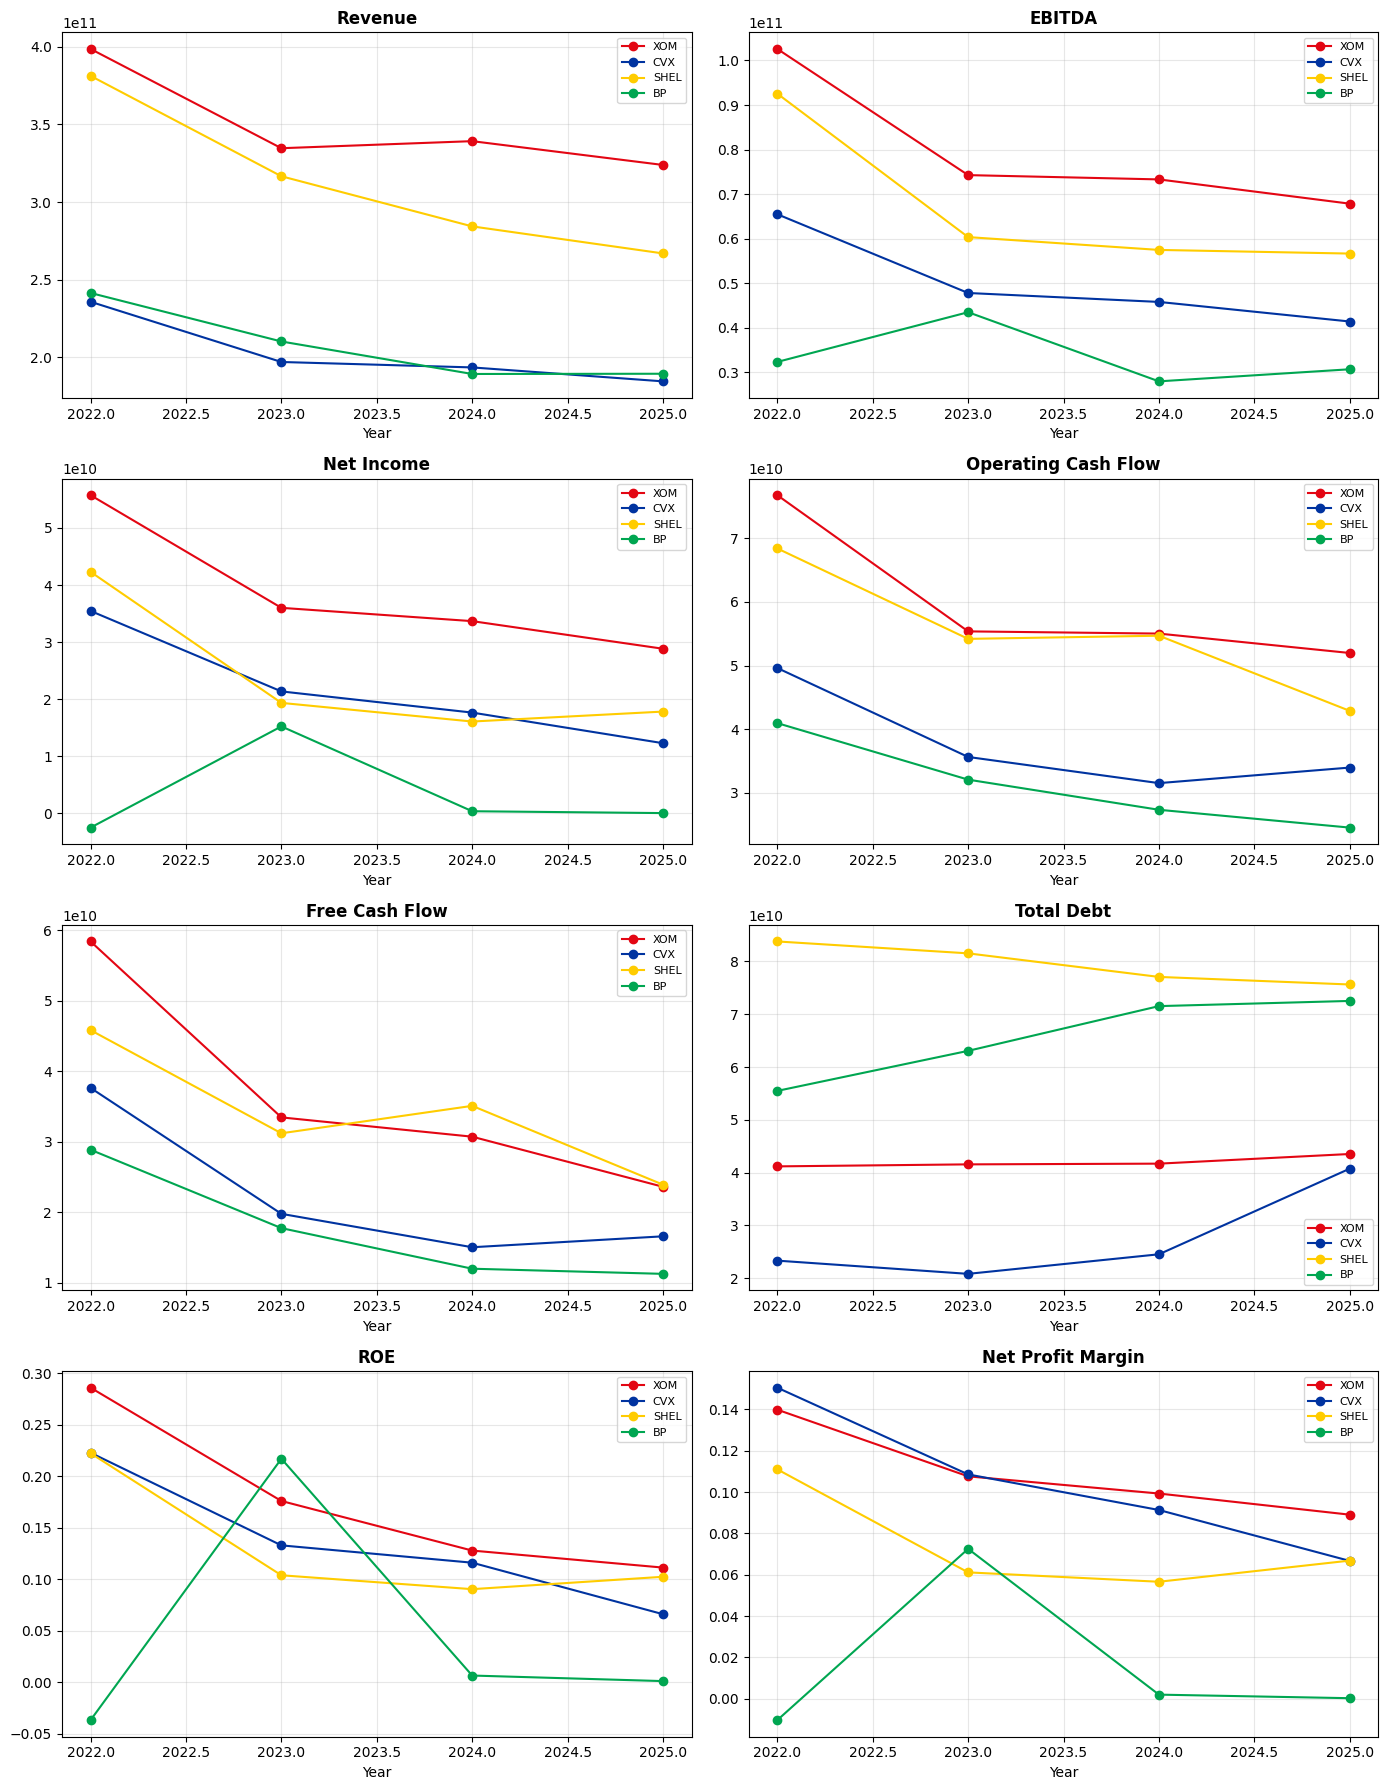

In [48]:
import matplotlib.pyplot as plt

metrics_to_plot = {
    "Total Revenue": "Revenue", "EBITDA": "EBITDA", "Net Income": "Net Income",
    "Operating Cash Flow": "Operating Cash Flow", "Free Cash Flow": "Free Cash Flow",
    "Total Debt": "Total Debt", "ROE": "ROE", "Net Profit Margin": "Net Profit Margin",
}
colors = {"BP": "#00A651", "CVX": "#0033A0", "SHEL": "#FFCC00", "XOM": "#E30613"}

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, (col, title) in enumerate(metrics_to_plot.items()):
    ax = axes[i]
    for ticker in TICKERS:
        subset = kpi_df[kpi_df["Ticker"] == ticker].sort_values("Year")
        ax.plot(subset["Year"], subset[col], marker="o", label=ticker, color=colors[ticker])
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Year")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(BASE_PATH / "trend_analysis_2022_2025.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 11 — Phase 15: Benchmarking Table (2025 Snapshot)

In [49]:
benchmark_year = 2025
latest = kpi_df[kpi_df["Year"] == benchmark_year].set_index("Ticker")

benchmark_cols = {
    "Revenue Growth": "Revenue Growth", "EBITDA Margin": "EBITDA Margin",
    "Net Profit Margin": "Net Margin", "ROA": "ROA", "ROE": "ROE", "ROIC": "ROIC",
    "Current Ratio": "Current Ratio", "Debt to Equity": "Debt/Equity",
    "Net Debt to EBITDA": "Net Debt/EBITDA", "FCF Margin": "FCF Margin",
    "Asset Turnover": "Asset Turnover",
}
benchmark_table = latest[list(benchmark_cols.keys())].rename(columns=benchmark_cols)
benchmark_table = benchmark_table.loc[TICKERS].T

print(f"COMPANY BENCHMARKING -- {benchmark_year}")
benchmark_table.round(4)

COMPANY BENCHMARKING -- 2025


Ticker,XOM,CVX,SHEL,BP
Revenue Growth,-0.0452,-0.0464,-0.0613,0.0008
EBITDA Margin,0.2095,0.2246,0.2123,0.1621
Net Margin,0.0891,0.0667,0.0668,0.0003
ROA,0.0642,0.0380,0.0482,0.0002
ROE,0.1112,0.0660,0.1023,0.0010
ROIC,0.0954,0.0583,0.0842,0.0769
Current Ratio,1.1528,1.1547,1.3004,1.2632
Debt/Equity,0.1678,0.2186,0.4338,1.3671
Net Debt/EBITDA,0.3911,0.7973,0.3014,0.6972
FCF Margin,0.0729,0.0900,0.0896,0.0595


## Section 12 — Phase 16: Financial Scoring & Ranking

In [50]:
scoring_year = 2025
score_df = kpi_df[kpi_df["Year"] == scoring_year].set_index("Ticker").copy()

categories = {
    "Profitability": (["EBITDA Margin", "Operating Margin", "Net Profit Margin", "ROA", "ROE", "ROIC"], True),
    "Liquidity": (["Current Ratio", "Quick Ratio"], True),
    "Financial Risk": (["Debt to Equity", "Net Debt to EBITDA"], False),
    "Cash Generation": (["OCF Margin", "FCF Margin"], True),
    "Growth": (["Revenue Growth", "EBITDA Growth", "Net Income Growth"], True),
}

def normalize(series, higher_is_better=True):
    norm = (series - series.min()) / (series.max() - series.min())
    return norm if higher_is_better else 1 - norm

category_scores = pd.DataFrame(index=score_df.index)
for cat_name, (cols, higher_better) in categories.items():
    normed = pd.concat([normalize(score_df[c], higher_better) for c in cols], axis=1)
    category_scores[cat_name] = normed.mean(axis=1)

category_scores["Overall Score"] = category_scores.mean(axis=1) * 100
category_scores = category_scores.sort_values("Overall Score", ascending=False)

print(f"FINANCIAL SCORING -- {scoring_year}")
category_scores.round(1)

FINANCIAL SCORING -- 2025


,Profitability,Liquidity,Financial Risk,Cash Generation,Growth,Overall Score
Ticker,,,,,,
SHEL,0.8,1.0,0.9,0.8,0.5,79.0
XOM,1.0,0.0,0.9,0.5,0.4,54.9
CVX,0.5,0.2,0.5,1.0,0.3,49.0
BP,0.1,0.8,0.1,0.0,0.7,32.6


## Section 13 — Phase 18: Oil & Gas Sector-Specific Analysis

In [51]:
sector_analysis = pd.DataFrame(index=TICKERS)

for ticker in TICKERS:
    company_data = kpi_df[kpi_df["Ticker"] == ticker].sort_values("Year")

    sector_analysis.loc[ticker, "Revenue Volatility"] = company_data["Total Revenue"].std() / company_data["Total Revenue"].mean()
    sector_analysis.loc[ticker, "EBITDA Volatility"] = company_data["EBITDA"].std() / company_data["EBITDA"].mean()
    sector_analysis.loc[ticker, "Net Margin Stability (StdDev)"] = company_data["Net Profit Margin"].std()
    sector_analysis.loc[ticker, "Avg CapEx Intensity"] = company_data["CapEx to Revenue"].mean()
    sector_analysis.loc[ticker, "Avg FCF Margin"] = company_data["FCF Margin"].mean()
    sector_analysis.loc[ticker, "Avg Net Debt/EBITDA"] = company_data["Net Debt to EBITDA"].mean()
    sector_analysis.loc[ticker, "Avg Asset Turnover"] = company_data["Asset Turnover"].mean()
    sector_analysis.loc[ticker, "Avg ROE"] = company_data["ROE"].mean()

print("OIL & GAS SECTOR-SPECIFIC ANALYSIS (2022-2025 cycle)")
sector_analysis.round(4)

OIL & GAS SECTOR-SPECIFIC ANALYSIS (2022-2025 cycle)


,Revenue Volatility,EBITDA Volatility,Net Margin Stability (StdDev),Avg CapEx Intensity,Avg FCF Margin,Avg Net Debt/EBITDA,Avg Asset Turnover,Avg ROE
XOM,0.0964,0.1968,0.0219,0.0677,0.1025,0.1890,0.8598,0.1751
CVX,0.1119,0.2110,0.0353,0.0776,0.1070,0.3757,0.7473,0.1343
SHEL,0.1615,0.2586,0.0251,0.0680,0.1079,0.2289,0.7735,0.1296
BP,0.1187,0.2028,0.0380,0.0672,0.0818,0.7210,0.7344,0.0469


## Section 14 — Data Quality & Receivables Audit Sheets

In [52]:
data_quality = pd.DataFrame({
    "Field": kpi_df.columns,
    "Populated": [kpi_df[c].notna().sum() for c in kpi_df.columns],
    "Missing": [kpi_df[c].isna().sum() for c in kpi_df.columns],
})
data_quality["Population_%"] = (data_quality["Populated"] / len(kpi_df) * 100).round(1)

receivables_check = kpi_df[["Ticker", "Year", "Receivables", "Receivables_Source"]].copy()
receivables_check["Status"] = np.where(receivables_check["Receivables"].notna(), "Available", "Missing")

print("Data quality and receivables audit sheets ready.")

Data quality and receivables audit sheets ready.


## Section 15 — Final Excel Export (12-sheet workbook)

In [55]:
with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:

    kpi_df.to_excel(writer, sheet_name="KPI_Data", index=False)

    kpi_df[["Ticker", "Year", "Current Ratio", "Quick Ratio", "Cash Ratio",
            "Debt to Equity", "Debt to Assets", "Net Debt to EBITDA",
            "ROA", "ROE", "ROIC"]].to_excel(writer, sheet_name="Ratios", index=False)

    kpi_df[["Ticker", "Year"] + growth_cols].to_excel(writer, sheet_name="Growth", index=False)

    kpi_df[["Ticker", "Year", "Gross Margin", "Operating Margin", "EBITDA Margin",
            "EBIT Margin", "Net Profit Margin", "ROA", "ROE", "ROIC"]].to_excel(
                writer, sheet_name="Profitability", index=False)

    kpi_df[["Ticker", "Year", "Current Ratio", "Quick Ratio", "Cash Ratio",
            "Working Capital"]].to_excel(writer, sheet_name="Liquidity", index=False)

    kpi_df[["Ticker", "Year", "Debt to Equity", "Debt to Assets", "Net Debt to EBITDA",
            "Equity Ratio"]].to_excel(writer, sheet_name="Leverage", index=False)

    kpi_df[["Ticker", "Year", "Asset Turnover", "Inventory Turnover", "Receivables Turnover",
            "Days Sales Outstanding", "Days Inventory Outstanding"]].to_excel(
                writer, sheet_name="Efficiency", index=False)

    kpi_df[["Ticker", "Year", "OCF Margin", "OCF to Net Income", "FCF Margin",
            "FCF to Net Income", "CapEx to Revenue"]].to_excel(writer, sheet_name="Cash_Flow", index=False)

    benchmark_table.to_excel(writer, sheet_name="Benchmark")
    category_scores.to_excel(writer, sheet_name="Ranking")
    sector_analysis.to_excel(writer, sheet_name="Sector_Analysis")
    data_quality.to_excel(writer, sheet_name="Data_Quality", index=False)
    receivables_check.to_excel(writer, sheet_name="Receivables_Check", index=False)

print("Workbook saved:", OUTPUT_XLSX)

Workbook saved: D:\Mohamed Mounir\financial analysis\Oil and Gas\data\processed\Corporate_Financial_Analysis_2022_2025.xlsx


## Section 16 — Save a Checkpoint (so a kernel restart never loses today's work again)

In [56]:
kpi_df.to_csv(BASE_PATH / "kpi_df_final_checkpoint.csv", index=False)
print("Checkpoint saved. To restore in a future session without re-running everything above:")
print('kpi_df = pd.read_csv(BASE_PATH / "kpi_df_final_checkpoint.csv")')

Checkpoint saved. To restore in a future session without re-running everything above:
kpi_df = pd.read_csv(BASE_PATH / "kpi_df_final_checkpoint.csv")


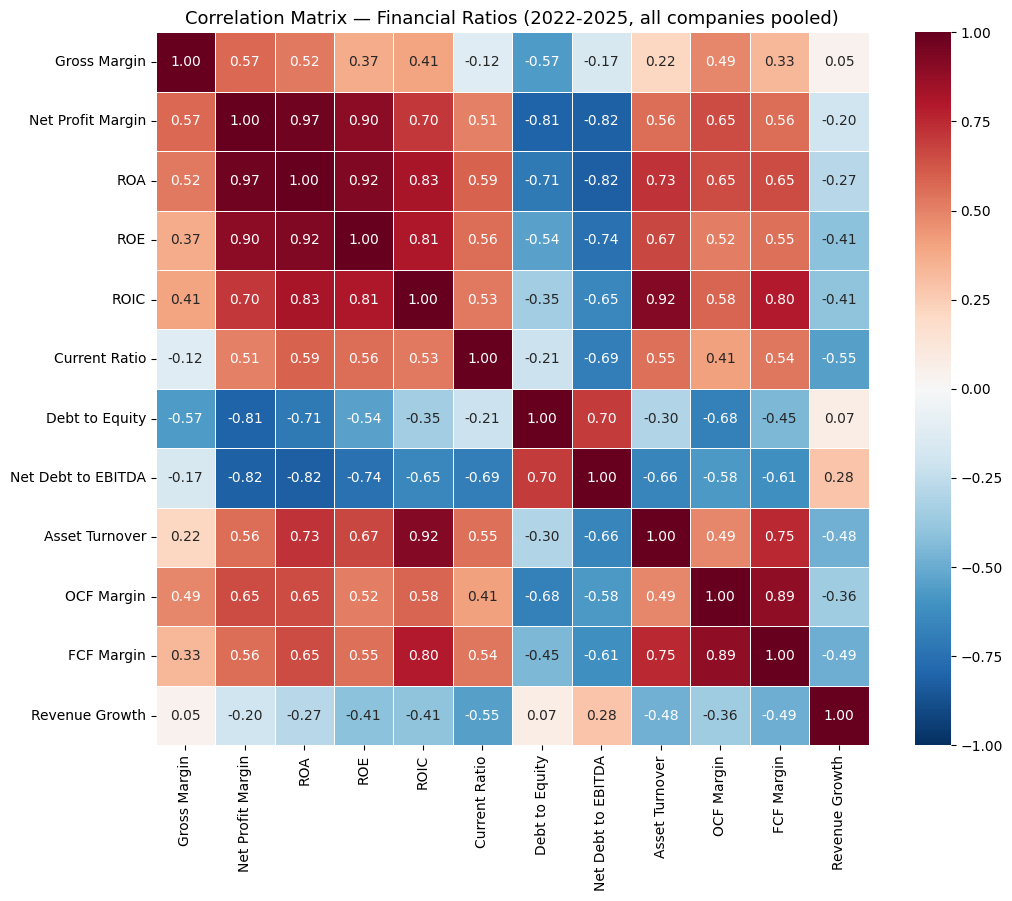

In [57]:
# ================================================================
# CORRELATION ANALYSIS
# ================================================================
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = [
    "Gross Margin", "Net Profit Margin", "ROA", "ROE", "ROIC",
    "Current Ratio", "Debt to Equity", "Net Debt to EBITDA",
    "Asset Turnover", "OCF Margin", "FCF Margin", "Revenue Growth",
]

corr_matrix = kpi_df[corr_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation Matrix — Financial Ratios (2022-2025, all companies pooled)", fontsize=13)
plt.tight_layout()
plt.savefig(BASE_PATH / "correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [58]:
# ================================================================
# REGRESSION: What drives ROE across the panel?
# ================================================================
import statsmodels.api as sm

reg_df = kpi_df[["ROE", "Debt to Equity", "Asset Turnover", "Net Profit Margin"]].dropna()

X = reg_df[["Debt to Equity", "Asset Turnover", "Net Profit Margin"]]
X = sm.add_constant(X)
y = reg_df["ROE"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    ROE   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     44.52
Date:                Sun, 06 Sep 2026   Prob (F-statistic):           8.88e-07
Time:                        19:52:43   Log-Likelihood:                 36.591
No. Observations:                  16   AIC:                            -65.18
Df Residuals:                      12   BIC:                            -62.09
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.1773      0.05

In [59]:
# ================================================================
# DUPONT DECOMPOSITION
# ROE = Net Profit Margin x Asset Turnover x Equity Multiplier
# ================================================================
kpi_df["Equity Multiplier"] = kpi_df["Total Assets"] / kpi_df["Stockholders Equity"]

kpi_df["ROE (DuPont Check)"] = (
    kpi_df["Net Profit Margin"] * kpi_df["Asset Turnover"] * kpi_df["Equity Multiplier"]
)

# Sanity check: this should match your existing ROE column almost exactly
dupont_check = kpi_df[["Ticker", "Year", "ROE", "ROE (DuPont Check)"]].copy()
dupont_check["Difference"] = (dupont_check["ROE"] - dupont_check["ROE (DuPont Check)"]).abs()

print("DUPONT IDENTITY CHECK (should be ~0 difference)")
print(dupont_check)

dupont_table = kpi_df[["Ticker", "Year", "Net Profit Margin", "Asset Turnover",
                          "Equity Multiplier", "ROE"]].sort_values(["Ticker", "Year"])
print("\nDUPONT COMPONENTS")
print(dupont_table)

DUPONT IDENTITY CHECK (should be ~0 difference)
   Ticker  Year       ROE  ROE (DuPont Check)    Difference
0      BP  2022 -0.036816           -0.036816  6.938894e-18
1      BP  2023  0.216823            0.216823  0.000000e+00
2      BP  2024  0.006431            0.006431  0.000000e+00
3      BP  2025  0.001037            0.001037  0.000000e+00
4     CVX  2022  0.222655            0.222655  2.775558e-17
5     CVX  2023  0.132762            0.132762  2.775558e-17
6     CVX  2024  0.115948            0.115948  1.387779e-17
7     CVX  2025  0.065964            0.065964  1.387779e-17
8    SHEL  2022  0.222127            0.222127  2.775558e-17
9    SHEL  2023  0.103742            0.103742  0.000000e+00
10   SHEL  2024  0.090260            0.090260  1.387779e-17
11   SHEL  2025  0.102281            0.102281  0.000000e+00
12    XOM  2022  0.285774            0.285774  5.551115e-17
13    XOM  2023  0.175828            0.175828  0.000000e+00
14    XOM  2024  0.127718            0.127718  0.000

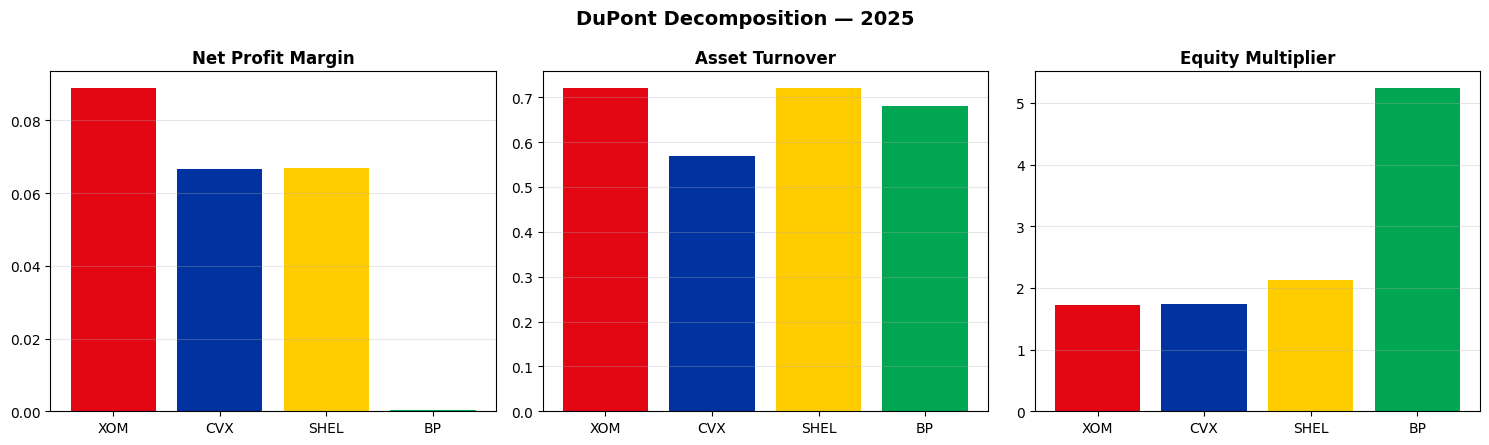

In [60]:
import matplotlib.pyplot as plt
import numpy as np

dupont_2025 = kpi_df[kpi_df["Year"] == 2025].set_index("Ticker").loc[TICKERS]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
components = ["Net Profit Margin", "Asset Turnover", "Equity Multiplier"]
colors_list = [colors[t] for t in TICKERS]

for ax, comp in zip(axes, components):
    ax.bar(TICKERS, dupont_2025[comp], color=colors_list)
    ax.set_title(comp, fontsize=12, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("DuPont Decomposition — 2025", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(BASE_PATH / "dupont_decomposition_2025.png", dpi=150, bbox_inches="tight")
plt.show()

In [61]:
# ================================================================
# CLUSTERING & PCA — Formalizing Company Health Tiers
# ================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Use 2025 snapshot, full ratio set (informed by the correlation/regression work --
# these are the metrics that actually differentiate the companies, not just anything)
cluster_features = [
    "Net Profit Margin", "ROA", "ROE", "ROIC",
    "Debt to Equity", "Net Debt to EBITDA", "Equity Multiplier",
    "Current Ratio", "Asset Turnover", "OCF Margin", "FCF Margin",
]

cluster_df = kpi_df[kpi_df["Year"] == 2025].set_index("Ticker")[cluster_features].copy()

# Standardize -- essential before K-Means/PCA since these ratios are on very
# different scales (margins ~0-0.3 vs Equity Multiplier ~1-5)
scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_df)

# PCA to 2 dimensions for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

print("Explained variance by component:", pca.explained_variance_ratio_)
print("Cumulative:", pca.explained_variance_ratio_.cumsum())

pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"], index=cluster_df.index)

# K-Means -- only 4 companies, so k=2 or k=3 is realistic (k=4 would just
# put every company in its own cluster, which isn't clustering)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
pca_df["Cluster"] = kmeans.fit_predict(scaled)

print("\nCLUSTER ASSIGNMENTS")
print(pca_df)

Explained variance by component: [0.58826649 0.31697044]
Cumulative: [0.58826649 0.90523694]

CLUSTER ASSIGNMENTS
             PC1       PC2  Cluster
Ticker                             
BP      4.360204  0.217823        1
CVX    -1.174220 -3.114898        0
SHEL   -1.135662  1.456949        0
XOM    -2.050323  1.440127        0


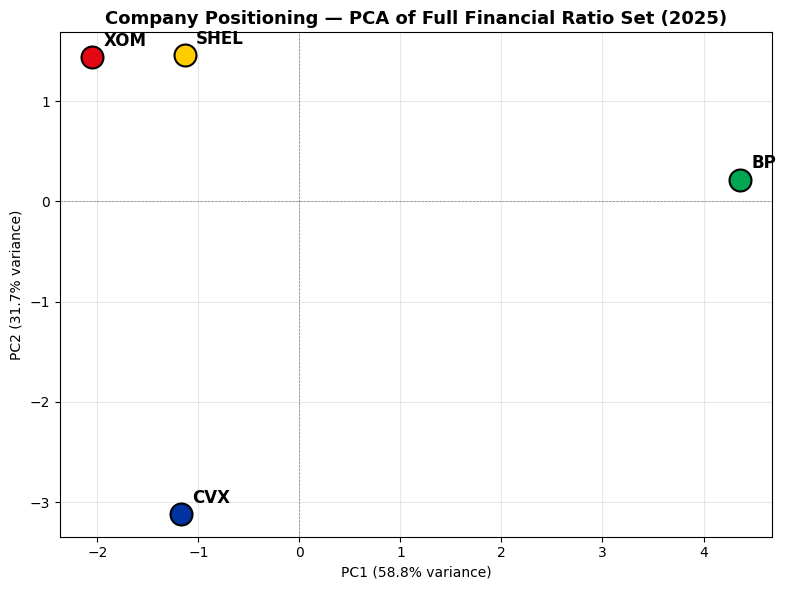

PCA LOADINGS (what each axis represents)
                         PC1       PC2
Equity Multiplier   0.390080  0.064050
Debt to Equity      0.388538  0.072671
Current Ratio       0.184008  0.255798
Net Debt to EBITDA  0.179947 -0.462529
Asset Turnover     -0.001226  0.535526
ROIC               -0.069754  0.505780
FCF Margin         -0.296001 -0.179090
OCF Margin         -0.325073 -0.295260
ROE                -0.371846  0.171938
ROA                -0.377350  0.135408
Net Profit Margin  -0.389638  0.038712


In [62]:
# ================================================================
# VISUALIZE: PCA SCATTER WITH CLUSTER COLORING
# ================================================================
fig, ax = plt.subplots(figsize=(8, 6))

for ticker in TICKERS:
    row = pca_df.loc[ticker]
    ax.scatter(row["PC1"], row["PC2"], s=250, color=colors[ticker],
               edgecolors="black", linewidths=1.5, zorder=3)
    ax.annotate(ticker, (row["PC1"], row["PC2"]), fontsize=12, fontweight="bold",
                xytext=(8, 8), textcoords="offset points")

ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.5, linestyle="--")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("Company Positioning — PCA of Full Financial Ratio Set (2025)", fontsize=13, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(BASE_PATH / "pca_company_positioning_2025.png", dpi=150, bbox_inches="tight")
plt.show()

# What's driving each PC -- important for interpreting the axes, not just the positions
loadings = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2"], index=cluster_features)
print("PCA LOADINGS (what each axis represents)")
print(loadings.sort_values("PC1", ascending=False))

In [63]:
# ================================================================
# BUILD ANNUAL STOCK RETURNS FROM DAILY PRICE DATA
# ================================================================
import yfinance as yf

# If you don't already have a fresh 'prices' dataframe in memory, pull it:
price_data = yf.download(TICKERS, start="2021-12-01", end="2025-12-31", group_by="ticker")

annual_returns = []
for ticker in TICKERS:
    px = price_data[ticker]["Close"].dropna()
    px.index = pd.to_datetime(px.index)
    yearly_close = px.resample("YE").last()  # last trading price of each calendar year
    yearly_return = yearly_close.pct_change()
    for year, ret in yearly_return.items():
        if year.year in [2022, 2023, 2024, 2025]:
            annual_returns.append({"Ticker": ticker, "Year": year.year, "Stock Return": ret})

returns_df = pd.DataFrame(annual_returns)
print(returns_df)

C:\Users\Ahmed Mounir\AppData\Local\Temp\ipykernel_8452\1880980130.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data = yf.download(TICKERS, start="2021-12-01", end="2025-12-31", group_by="ticker")
[*********************100%***********************]  4 of 4 completed


   Ticker  Year  Stock Return
0     XOM  2022      0.874091
1     XOM  2023     -0.062615
2     XOM  2024      0.112616
3     XOM  2025      0.166036
4     CVX  2022      0.584624
5     CVX  2023     -0.136327
6     CVX  2024      0.012871
7     CVX  2025      0.100322
8    SHEL  2022      0.348105
9    SHEL  2023      0.201934
10   SHEL  2024     -0.008722
11   SHEL  2025      0.227463
12     BP  2022      0.370065
13     BP  2023      0.060009
14     BP  2024     -0.118388
15     BP  2025      0.246147


In [64]:
kpi_df = kpi_df.merge(returns_df, on=["Ticker", "Year"], how="left")

# Shift fundamentals forward one year per company: this year's fundamentals
# predicting NEXT year's stock return -- the only valid predictive framing
predictor_cols = ["ROE", "Net Profit Margin", "Revenue Growth", "Debt to Equity",
                    "FCF Margin", "Asset Turnover"]

kpi_df = kpi_df.sort_values(["Ticker", "Year"])
for col in predictor_cols:
    kpi_df[f"{col} (Prior Year)"] = kpi_df.groupby("Ticker")[col].shift(1)

predict_df = kpi_df.dropna(subset=[f"{c} (Prior Year)" for c in predictor_cols] + ["Stock Return"])
print(predict_df[["Ticker", "Year"] + [f"{c} (Prior Year)" for c in predictor_cols] + ["Stock Return"]])
print("\nUsable rows for prediction:", len(predict_df))

   Ticker  Year  ROE (Prior Year)  Net Profit Margin (Prior Year)  \
2      BP  2024          0.216823                        0.072522   
3      BP  2025          0.006431                        0.002014   
6     CVX  2024          0.132762                        0.108520   
7     CVX  2025          0.115948                        0.091312   
10   SHEL  2024          0.103742                        0.061143   
11   SHEL  2025          0.090260                        0.056607   
14    XOM  2024          0.175828                        0.107590   
15    XOM  2025          0.127718                        0.099279   

    Revenue Growth (Prior Year)  Debt to Equity (Prior Year)  \
2                     -0.129507                     0.897443   
3                     -0.099676                     1.207626   
6                     -0.164621                     0.129451   
7                     -0.017769                     0.161117   
10                    -0.169661                     0.4369

In [65]:
predictor_cols = ["ROE", "Net Profit Margin", "Debt to Equity", "FCF Margin", "Asset Turnover"]

kpi_df = kpi_df.sort_values(["Ticker", "Year"])
for col in predictor_cols:
    kpi_df[f"{col} (Prior Year)"] = kpi_df.groupby("Ticker")[col].shift(1)

predict_df = kpi_df.dropna(subset=[f"{c} (Prior Year)" for c in predictor_cols] + ["Stock Return"])
print("Usable rows for prediction:", len(predict_df))
predict_df[["Ticker", "Year"] + [f"{c} (Prior Year)" for c in predictor_cols] + ["Stock Return"]]

Usable rows for prediction: 12


,Ticker,Year,ROE (Prior Year),Net Profit Margin (Prior Year),Debt to Equity (Prior Year),FCF Margin (Prior Year),Asset Turnover (Prior Year),Stock Return
1,BP,2023,-0.036816,-0.010303,0.821474,0.119569,0.837818,0.060009
2,BP,2024,0.216823,0.072522,0.897443,0.084491,0.749677,-0.118388
3,BP,2025,0.006431,0.002014,1.207626,0.063430,0.670327,0.246147
5,CVX,2023,0.222655,0.150456,0.146526,0.159632,0.914663,-0.136327
6,CVX,2024,0.132762,0.108520,0.129451,0.100450,0.752633,0.012871
7,CVX,2025,0.115948,0.091312,0.161117,0.077781,0.752765,0.100322
9,SHEL,2023,0.222127,0.110956,0.439933,0.120148,0.860707,0.201934
10,SHEL,2024,0.103742,0.061143,0.436966,0.098535,0.779334,-0.008722
11,SHEL,2025,0.090260,0.056607,0.432277,0.123407,0.733502,0.227463
13,XOM,2023,0.285774,0.139813,0.211193,0.146460,1.080224,-0.062615


In [66]:
# Remove the shared year-level effect -- isolate genuine cross-sectional signal
predict_df = predict_df.copy()
for col in predictor_cols:
    year_mean = predict_df.groupby("Year")[f"{col} (Prior Year)"].transform("mean")
    predict_df[f"{col} (Relative)"] = predict_df[f"{col} (Prior Year)"] - year_mean

year_mean_return = predict_df.groupby("Year")["Stock Return"].transform("mean")
predict_df["Stock Return (Relative)"] = predict_df["Stock Return"] - year_mean_return

print("RELATIVE (WITHIN-YEAR) CORRELATIONS")
for col in predictor_cols:
    corr = predict_df[f"{col} (Relative)"].corr(predict_df["Stock Return (Relative)"])
    print(f"{col} (Relative) vs Stock Return (Relative): {corr:.3f}")

RELATIVE (WITHIN-YEAR) CORRELATIONS
ROE (Relative) vs Stock Return (Relative): -0.323
Net Profit Margin (Relative) vs Stock Return (Relative): -0.321
Debt to Equity (Relative) vs Stock Return (Relative): 0.184
FCF Margin (Relative) vs Stock Return (Relative): -0.289
Asset Turnover (Relative) vs Stock Return (Relative): -0.221
